In [3]:
import pandas as pd
df = pd.read_csv("C:\\Users\\oshin\\Downloads\\new_file.csv")

In [2]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 485.4+ MB


In [4]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [4]:
df = df.dropna()

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

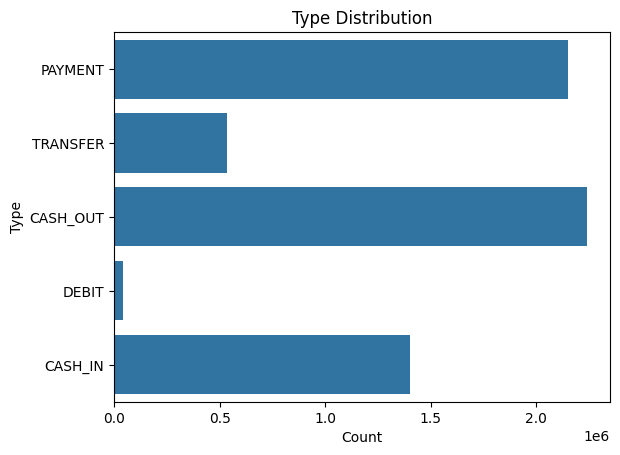

In [7]:
sns.countplot(df['type'])
plt.ylabel('Type')
plt.xlabel('Count')
plt.title('Type Distribution')
plt.show()

<Axes: xlabel='type', ylabel='amount'>

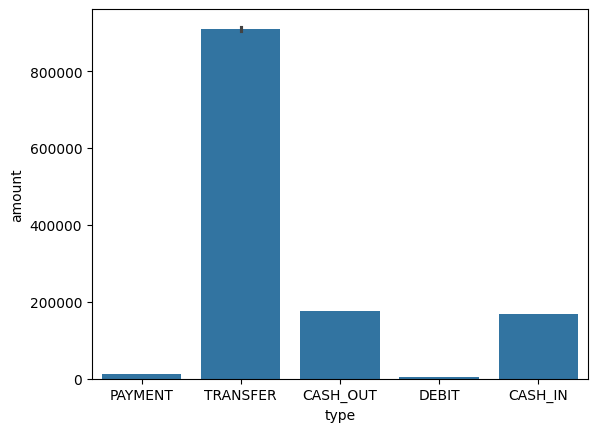

In [8]:
sns.barplot(x=df['type'],y=df['amount'])

In [9]:
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

In [10]:
numerical_features = df.select_dtypes(include = ['number'])

corre = numerical_features.corr()

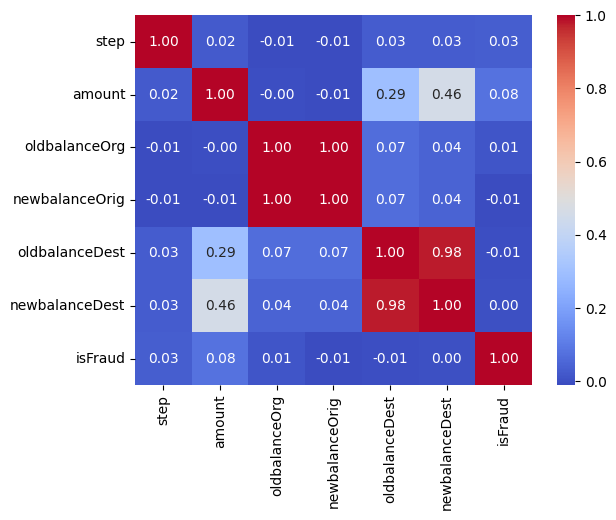

In [11]:
sns.heatmap(corre, annot=True, cmap='coolwarm',fmt='.2f')
plt.show()

In [5]:
#dropping highly correlated variables
df =  df.drop(['oldbalanceOrg','oldbalanceDest'],axis = 1)

In [6]:
x=df.drop(['isFraud','nameOrig','nameDest'],axis=1)
y= df['isFraud']

In [14]:
x.shape

(6362620, 5)

In [7]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.2,random_state=42)

In [15]:
pip install imblearn

Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ---------------------------------------- 3/3 [imblearn]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\oshin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [24]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# One-hot encode the 'type' column in x_train
x_train_encoded = pd.get_dummies(x_train, columns=['type'], drop_first=True)

sm = SMOTE(random_state=42)
x_train_res, y_train_res = sm.fit_resample(x_train_encoded, y_train)

In [25]:
print('Shape of x_train after SMOTE:', x_train_res.shape)
print('Shape of y_train after SMOTE:', y_train_res.shape)
print('\nValue counts of y_train after SMOTE:')
print(y_train_res.value_counts())

Shape of x_train after SMOTE: (10167006, 8)
Shape of y_train after SMOTE: (10167006,)

Value counts of y_train after SMOTE:
isFraud
0    5083503
1    5083503
Name: count, dtype: int64


In [26]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\oshin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [27]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [28]:
models = [LogisticRegression(),RandomForestClassifier(n_estimators=7,criterion='entropy',random_state =7),XGBClassifier()]

In [29]:
for i in range(len(models)):
  # Preprocess x_test to match x_train_res's columns
  # One-hot encode the 'type' column in x_test
  x_test_processed = pd.get_dummies(x_test, columns=['type'], drop_first=True)

  # Ensure x_test_processed has the same columns as x_train_res, filling missing with 0
  # This is crucial if a 'type' category present in x_train_res is not in x_test, or vice-versa
  for col in x_train_res.columns:
      if col not in x_test_processed.columns:
          x_test_processed[col] = 0
  # Reorder columns to match x_train_res
  x_test_processed = x_test_processed[x_train_res.columns]

  # Create mutable copies for the current iteration
  current_x_train = x_train_res.copy()
  current_x_test = x_test_processed.copy()

  models[i].fit(current_x_train,y_train_res)
  print(f'{models[i]}:')
  print('Training accuracy:',models[i].score(current_x_train,y_train_res))
  y_pred = models[i].predict(current_x_test) # Use the processed x_test
  print('Testing accuracy:',accuracy_score(y_test,y_pred))
  print('Classification report:\n',classification_report(y_test,y_pred))
  print('Confusion matrix:\n',confusion_matrix(y_test,y_pred))
  print('='*50)

LogisticRegression():
Training accuracy: 0.8355421448556242
Testing accuracy: 0.8662453517576093
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.87      0.93   1270904
           1       0.01      0.78      0.01      1620

    accuracy                           0.87   1272524
   macro avg       0.50      0.82      0.47   1272524
weighted avg       1.00      0.87      0.93   1272524

Confusion matrix:
 [[1101050  169854]
 [    352    1268]]
RandomForestClassifier(criterion='entropy', n_estimators=7, random_state=7):
Training accuracy: 0.9992763848078775
Testing accuracy: 0.9867177357755139
Classification report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99   1270904
           1       0.07      0.81      0.13      1620

    accuracy                           0.99   1272524
   macro avg       0.54      0.90      0.56   1272524
weighted avg       1.00      0.99      0.99   

In [1]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\oshin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
from imblearn.combine import SMOTEENN
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. One-hot encode the 'type' column for both train and test sets
x_train_encoded = pd.get_dummies(x_train, columns=['type'], drop_first=True)
x_test_encoded = pd.get_dummies(x_test, columns=['type'], drop_first=True)

# Align columns of test set with train set (filling missing categories with 0)
x_test_encoded = x_test_encoded.reindex(columns=x_train_encoded.columns, fill_value=0)

# 2. Apply SMOTEENN to the training data
print("Applying SMOTEENN... (This might take a few minutes due to the dataset size)")
sme = SMOTEENN(random_state=42)
x_train_res, y_train_res = sme.fit_resample(x_train_encoded, y_train)
print(np.bincount(y_train_res))
print("Resampling complete.")

# 3. Define the models 
# (Increased Random Forest estimators to 100 for better generalization)
models = [
    LogisticRegression(max_iter=1000),
    RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=12, random_state=7, n_jobs=-1),
    XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1)
]

# 4. Train and Evaluate
for model in models:
    model_name = model.__class__.__name__
    print(f"\n==================== {model_name} ====================")
    
    # Fit model on resampled training data
    model.fit(x_train_res, y_train_res)
    
    # Calculate training accuracy on the resampled set
    train_acc = model.score(x_train_res, y_train_res)
    print(f'Training accuracy (Resampled): {train_acc:.4f}')
    
    # Predict on the original, untouched testing set
    y_pred = model.predict(x_test_encoded)
    
    print(f'Testing accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print('\nClassification report:')
    print(classification_report(y_test, y_pred))
    print('Confusion matrix:')
    print(confusion_matrix(y_test, y_pred))

Applying SMOTEENN... (This might take a few minutes due to the dataset size)
[4713831 4868688]
Resampling complete.

==================== LogisticRegression ====================
Training accuracy (Resampled): 0.8578
Testing accuracy: 0.7991

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89   1270904
           1       0.01      0.88      0.01      1620

    accuracy                           0.80   1272524
   macro avg       0.50      0.84      0.45   1272524
weighted avg       1.00      0.80      0.89   1272524

Confusion matrix:
[[1015412  255492]
 [    193    1427]]

==================== RandomForestClassifier ====================
Training accuracy (Resampled): 0.9405
Testing accuracy: 0.9646

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1270904
           1       0.03      0.90      0.06      1620

    accuracy                      

In [10]:
# Change "RandomUnderSampling" to "RandomUnderSampler"
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. One-hot encode the 'type' column for both train and test sets
x_train_encoded = pd.get_dummies(x_train, columns=['type'], drop_first=True)
x_test_encoded = pd.get_dummies(x_test, columns=['type'], drop_first=True)

# Align columns of test set with train set (filling missing categories with 0)
x_test_encoded = x_test_encoded.reindex(columns=x_train_encoded.columns, fill_value=0)

# 2. Apply Random Under-Sampling to the training data
print("Applying Random Under-Sampling...")
rus = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
x_train_res, y_train_res = rus.fit_resample(x_train_encoded, y_train)

print(f"Resampled training class distribution: {np.bincount(y_train_res)}")

# 3. Define the models with class weights
models = [
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    RandomForestClassifier(n_estimators=100, criterion='entropy', max_depth=12, class_weight='balanced', random_state=7, n_jobs=-1),
    XGBClassifier(n_estimators=100, scale_pos_weight=10, random_state=42, n_jobs=-1) 
]

# 4. Train and Evaluate
for model in models:
    model_name = model.__class__.__name__
    print(f"\n==================== {model_name} ====================")
    
    # Fit model on the undersampled training data
    model.fit(x_train_res, y_train_res)
    
    # Calculate training accuracy on the resampled set
    train_acc = model.score(x_train_res, y_train_res)
    print(f'Training accuracy (Undersampled): {train_acc:.4f}')
    
    # Predict on the original, untouched testing set
    y_pred = model.predict(x_test_encoded)
    
    print(f'Testing accuracy: {accuracy_score(y_test, y_pred):.4f}')
    print('\nClassification report:')
    print(classification_report(y_test, y_pred))
    print('Confusion matrix:')
    print(confusion_matrix(y_test, y_pred))

Applying Random Under-Sampling...
Resampled training class distribution: [65930  6593]

==================== LogisticRegression ====================
Training accuracy (Undersampled): 0.8088
Testing accuracy: 0.8024

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89   1270904
           1       0.01      0.88      0.01      1620

    accuracy                           0.80   1272524
   macro avg       0.50      0.84      0.45   1272524
weighted avg       1.00      0.80      0.89   1272524

Confusion matrix:
[[1019624  251280]
 [    191    1429]]

==================== RandomForestClassifier ====================
Training accuracy (Undersampled): 0.9687
Testing accuracy: 0.9730

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99   1270904
           1       0.04      0.89      0.08      1620

    accuracy                           0.97   1272524
   

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
import pandas as pd

# 1. Get the raw probability scores instead of binary 0 or 1 predictions
# (Assuming 'models[2]' is your trained XGBClassifier from the loop)
xgb_model = models[2] 
y_scores = xgb_model.predict_proba(x_test_encoded)[:, 1]

# 2. Calculate precision and recall for every possible threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_scores)

# 3. Store in a DataFrame to easily view the mapping
df_tradeoff = pd.DataFrame({
    'Threshold': thresholds,
    'Precision': precisions[:-1],
    'Recall': recalls[:-1]
})

# Print out what happens when you require high confidence thresholds
print("--- Visualizing High-Confidence Thresholds ---")
print(df_tradeoff[df_tradeoff['Threshold'] >= 0.90].head(15))

# 4. Set a strict custom threshold (e.g., 0.98 or 98% confidence required)
# You can adjust this number based on the printout above!
custom_threshold = 0.98  
y_pred_custom = (y_scores >= custom_threshold).astype(int)

# 5. Print the new metrics
print(f"\n==================== XGBoost (Threshold: {custom_threshold}) ====================")
print('Classification report:')
print(classification_report(y_test, y_pred_custom))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred_custom))

--- Visualizing High-Confidence Thresholds ---
        Threshold  Precision    Recall
454726   0.900017   0.199097  0.816667
454727   0.900060   0.199127  0.816667
454728   0.900076   0.199157  0.816667
454729   0.900090   0.199187  0.816667
454730   0.900097   0.199217  0.816667
454731   0.900114   0.199277  0.816667
454732   0.900161   0.199367  0.816667
454733   0.900177   0.199397  0.816667
454734   0.900194   0.199427  0.816667
454735   0.900199   0.199457  0.816667
454736   0.900200   0.199487  0.816667
454737   0.900205   0.199517  0.816667
454738   0.900207   0.199789  0.816667
454739   0.900218   0.199819  0.816667
454740   0.900237   0.199849  0.816667

==================== XGBoost (Threshold: 0.98) ====================
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.58      0.73      0.65      1620

    accuracy                           1.00   1272524
   macro avg       

C:\Users\oshin\AppData\Local\Temp\ipykernel_23972\2234889070.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance,


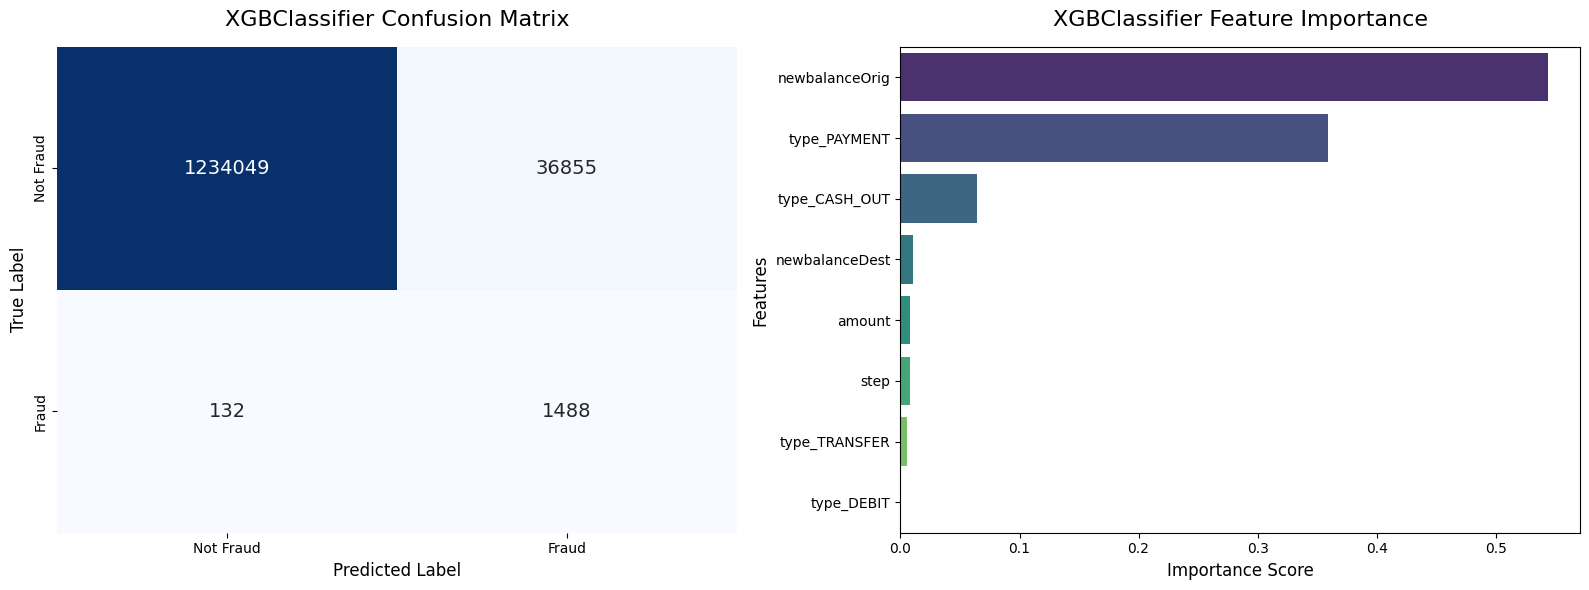

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming 'models[2]' is your trained XGBClassifier from the previous run
xgb_model = models[2]

# Set up a clean plotting area for two side-by-side visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------------
# 1. VISUALIZE THE CONFUSION MATRIX
# ------------------------------------------------------------------
# Get predictions on the test set
y_pred = xgb_model.predict(x_test_encoded)
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix as a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Fraud', 'Fraud'], 
            yticklabels=['Not Fraud', 'Fraud'],
            cbar=False, annot_kws={"size": 14})

axes[0].set_title('XGBClassifier Confusion Matrix', fontsize=16, pad=15)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)


# ------------------------------------------------------------------
# 2. VISUALIZE FEATURE IMPORTANCE
# ------------------------------------------------------------------
# Extract feature importance values from XGBoost
importances = xgb_model.feature_importances_
feature_names = x_train_encoded.columns

# Create a DataFrame to make sorting and plotting cleaner
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting the feature importances as a horizontal bar chart
sns.barplot(x='Importance', y='Feature', data=df_importance, 
            palette='viridis', ax=axes[1])

axes[1].set_title('XGBClassifier Feature Importance', fontsize=16, pad=15)
axes[1].set_xlabel('Importance Score', fontsize=12)
axes[1].set_ylabel('Features', fontsize=12)

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()